In [1]:
import subprocess

from glob import glob
import os
import h5py
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

os.environ["PATH"] += os.pathsep + "/scratch/projects/tacc/texlive/2025/bin/x86_64-linux"

rc = mpl.rcParams # Font structure is called rc now
rc['text.usetex'] = True # Tex fonts
rc['font.family'] = 'serif'
rc['font.size'] = 20
rc['xtick.labelsize'] = 15
rc['ytick.labelsize'] = 15
rc['lines.linewidth'] = 2
rc["axes.axisbelow"] = False
plt.rcParams['axes.formatter.min_exponent'] = 2
rc['axes.linewidth'] = 1.5
plt.rcParams["figure.figsize"] = (8, 6)

NUM_GHOSTS = 3

In [80]:
folder = "output_MR_dt"
data = {}

for filepath in sorted(glob(os.path.join(folder, "*.h5")))[0:110:1]:
    run_name = os.path.splitext(os.path.basename(filepath))[0]
    print(f"Reading {filepath}")

    with h5py.File(filepath, "r") as f:
        data[run_name] = {
            "t": f["t"][:],
            "r": f["r"][:],
            "u": f["u"][:],
            "v": f["v"][:],
            "lapse": f["lapse"][:],
            "phi": f["phi"][:],
            # "K": f["K"][:],
            "bh_mass": f["bh_mass"][:],
            "ah_radius": f["ah_radius"][:],
            # "Ham": f["Ham"][:],
            # "Mom": f["Mom"][:],
            "ampl": f.attrs["ampl"],
            # "wid": f.attrs["wid"],
            # "r0": f.attrs["r0"],
            # "Omega": f.attrs["Omega"],

        }


Reading output_MR_dt/run_0000.h5
Reading output_MR_dt/run_0001.h5
Reading output_MR_dt/run_0002.h5
Reading output_MR_dt/run_0003.h5
Reading output_MR_dt/run_0004.h5
Reading output_MR_dt/run_0005.h5
Reading output_MR_dt/run_0007.h5
Reading output_MR_dt/run_0008.h5
Reading output_MR_dt/run_0010.h5
Reading output_MR_dt/run_0011.h5
Reading output_MR_dt/run_0013.h5
Reading output_MR_dt/run_0015.h5
Reading output_MR_dt/run_0016.h5
Reading output_MR_dt/run_0023.h5
Reading output_MR_dt/run_0026.h5
Reading output_MR_dt/run_0028.h5
Reading output_MR_dt/run_0029.h5
Reading output_MR_dt/run_0031.h5
Reading output_MR_dt/run_0032.h5
Reading output_MR_dt/run_0034.h5
Reading output_MR_dt/run_0036.h5
Reading output_MR_dt/run_0037.h5
Reading output_MR_dt/run_0038.h5
Reading output_MR_dt/run_0040.h5
Reading output_MR_dt/run_0044.h5
Reading output_MR_dt/run_0045.h5
Reading output_MR_dt/run_0046.h5
Reading output_MR_dt/run_0048.h5
Reading output_MR_dt/run_0051.h5
Reading output_MR_dt/run_0053.h5
Reading ou

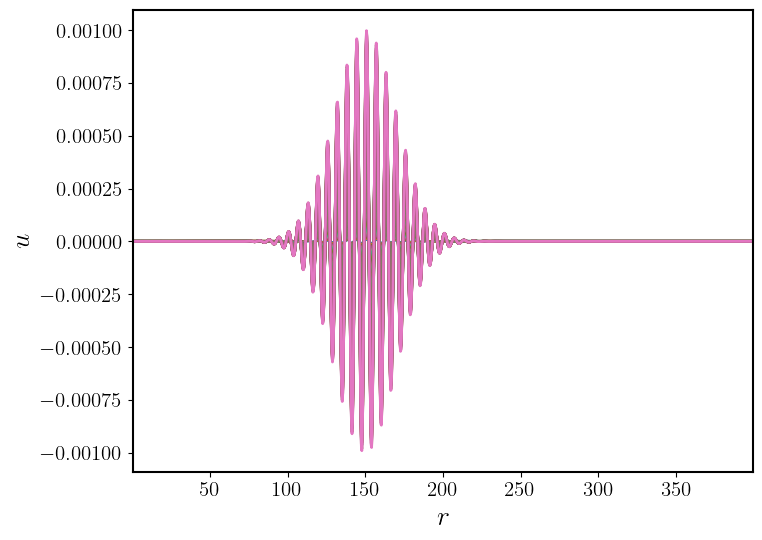

In [81]:
# Plot t_delay vs r
for run_name, run in data.items():
    plt.plot(run["r"], run["u"][0],label=r"$u=$"+" "+str(run["ampl"]))
plt.ylabel(r"$u$")
plt.xlabel(r"$r$")
plt.xlim([run["r"][NUM_GHOSTS],run["r"][-NUM_GHOSTS]])


# plt.legend(loc="best")
plt.show()

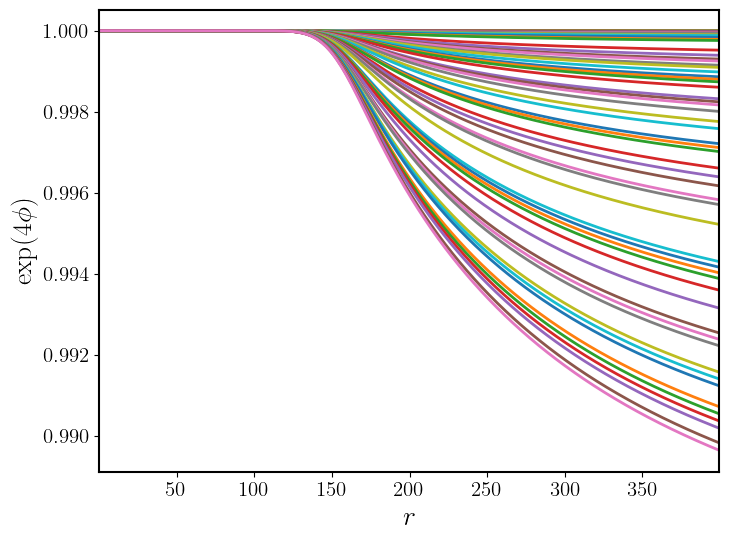

In [82]:
i = 0
# Plot rho vs r at given t
for run_name, run in data.items():
    plt.plot(run["r"], np.exp(2*run["phi"][i]),label=r"$\delta t=$"+" "+str(run["ampl"]))
plt.ylabel(r"$\exp(4\phi)$")
plt.xlabel(r"$r$")
plt.xlim([run["r"][NUM_GHOSTS],run["r"][-NUM_GHOSTS]])

# plt.legend(loc="best")
plt.show()

In [96]:
# Pick a simulation to plot

i_simulation = 0
run = data[list(data.keys())[i_simulation]]

NUM_GHOSTS = 3

t = run["t"]
r = run["r"]
u = run["u"]
v = run["v"]
phi = run["phi"]
lapse = run["lapse"]
ah_radius = run["ah_radius"]

num_points_t = len(lapse)

max_u = np.max(r*u)
min_u = np.min(r*u)

max_v = np.max(r*v)
min_v = np.min(r*v)

    
print("This run is ampl="+str(run["ampl"]))

This run is ampl=1e-05


In [91]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Create a figure and axes
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), facecolor="white")

# Initialize empty lines for the plots
line1, = ax1.plot([], [], color='k')
line2, = ax2.plot([], [], color='k')
line22, = ax2.plot([], [], color='r',ls="--")
line3, = ax3.plot([], [], color='k')
line4 = ax1.axvline(x=0, color='r', label="BH horizon")
line5 = ax2.axvline(x=0, color='r')
line6 = ax3.axvline(x=0, color='r')

# Set labels
ax1.set_ylabel(r"$ru$",fontsize=30)
ax2.set_ylabel(r"$rv$",fontsize=30)
ax3.set_ylabel(r"$\alpha$",fontsize=30)
ax3.set_xlabel(r"$r$",fontsize=30)

ax1.set_xticklabels([])
ax2.set_xticklabels([])

# Define the initialization function
def init():
    ax1.set_xlim(r[NUM_GHOSTS], r[-NUM_GHOSTS])
    ax2.set_xlim(r[NUM_GHOSTS], r[-NUM_GHOSTS])
    ax3.set_xlim(r[NUM_GHOSTS], r[-NUM_GHOSTS])


    ax1.set_ylim(1.1 * min_u, 1.1 * max_u)  # Set y-limits for rho
    ax2.set_ylim(1.1*min_v, 1.1*max_v)  # Adjust as needed for vr
    ax3.set_ylim(0, 1.1)
    
    # ax1.set_title(t[i])

    return line1, line2, line3, line4, line5, line6, 

# Define the update function for each frame
def update(i):
    line1.set_data(r, r*u[i])
    line2.set_data(r, r*v[i])
    line3.set_data(r, lapse[i])

    # axvline update: pass a list, not a scalar
    line4.set_xdata([ah_radius[i], ah_radius[i]])
    line5.set_xdata([ah_radius[i], ah_radius[i]])
    line6.set_xdata([ah_radius[i], ah_radius[i]])

    if ah_radius[i] > 0:
        ax1.legend(loc="upper right")

    return line1, line2, line3, line4, line5, line6,

# Create the animatio3
ani = FuncAnimation(fig, update, frames=range(0, num_points_t, 50), init_func=init, blit=True)

# print(max_rho)
plt.close()
# Display the animation interactively.
HTML(ani.to_jshtml())

In [85]:
from matplotlib.animation import FFMpegWriter
import matplotlib.animation as animation
import matplotlib

matplotlib.rcParams['animation.ffmpeg_path'] = '/opt/homebrew/bin/ffmpeg'  # Replace with actual path to ffmpeg

writer = FFMpegWriter(fps=10)
print("FFmpeg is ready!")

# ani.save("movies/output.mp4", writer=writer)

FFmpeg is ready!


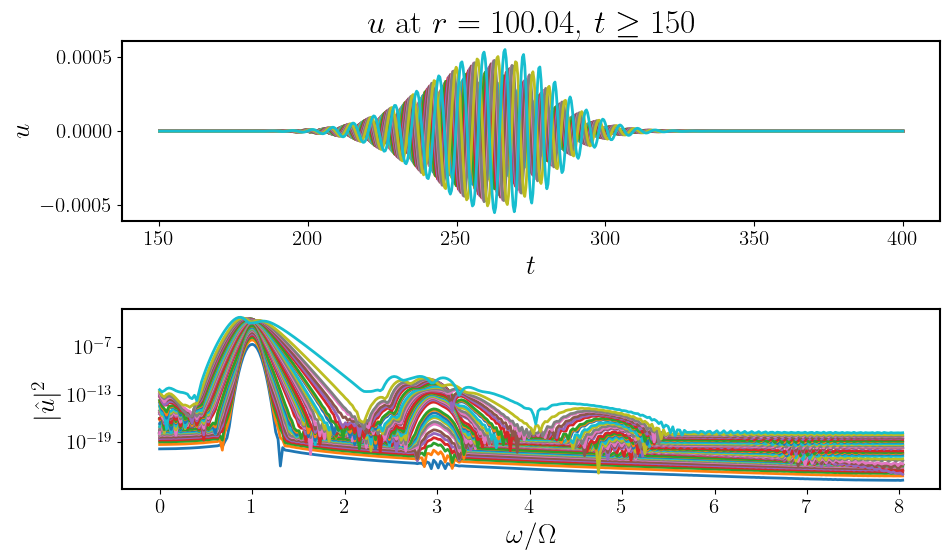

In [ ]:
r_extract = 100
i_t0_val  = 150

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

for key in list(data.keys())[::1]:
    run   = data[key]
    t     = run["t"]
    r     = run["r"]
    u     = run["u"]
    ampl  = run["ampl"]

    i_rext = np.argmin(np.abs(r - r_extract))
    i_t0   = np.argmin(np.abs(t - i_t0_val))
    t_trim = t[i_t0:]
    u_trim = u[i_t0:, i_rext]

    ax1.plot(t_trim, u_trim, label=rf"ampl={ampl:.3e}")

    dt    = t_trim[1] - t_trim[0]
    freqs  = np.fft.rfftfreq(len(u_trim), d=dt)
    omegas = 2 * np.pi * freqs          # convert to angular frequency
    power  = np.abs(np.fft.rfft(u_trim))**2
    ax2.plot(omegas, power, label=rf"ampl={ampl:.3e}")

ax1.set_ylabel(r"$u$")
ax1.set_xlabel(r"$t$")
ax1.set_title(rf"$u$ at $r = {r[i_rext]:.2f}$, $t \geq {i_t0_val}$")
# ax1.legend()

ax2.set_ylabel(r"$|\hat{u}|^2$")
ax2.set_xlabel(r"$\omega/\Omega$")
# ax2.axvline(x=1, color='r', ls='--', label=r"$\omega=\mu$")  # expected peak
ax2.set_yscale('log')
# ax2.legend()

plt.tight_layout()
plt.show()

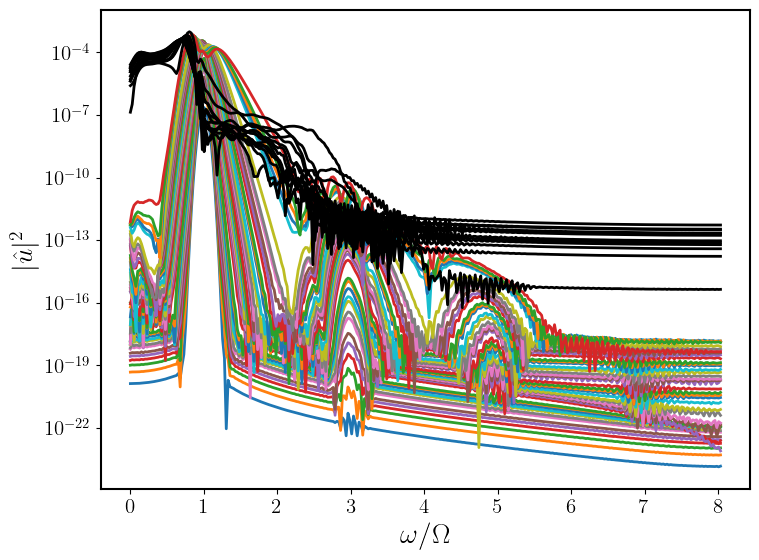

In [95]:
r_extract = 100
i_t0_val  = 150

fig, ax2 = plt.subplots(1, 1, figsize=(8, 6))

for key in list(data.keys())[::1]:
    run   = data[key]
    t     = run["t"]
    r     = run["r"]
    u     = run["u"]
    ampl  = run["ampl"]


    i_rext = np.argmin(np.abs(r - r_extract))
    i_t0   = np.argmin(np.abs(t - i_t0_val))
    t_trim = t[i_t0:]
    u_trim = u[i_t0:, i_rext]

    dt     = t_trim[1] - t_trim[0]
    freqs  = np.fft.rfftfreq(len(u_trim), d=dt)
    omegas = 2 * np.pi * freqs
    power  = np.abs(np.fft.rfft(u_trim))**2
    color = 'k' if run["bh_mass"].any() > 0 else None
    ax2.plot(omegas, power, color=color, label=rf"ampl={ampl:.3e}")

ax2.set_ylabel(r"$|\hat{u}|^2$")
ax2.set_xlabel(r"$\omega/\Omega$")
ax2.set_yscale('log')
# ax2.set_xlim([0,10])
# ax2.set_ylim([1e-20,1])

# ax2.legend(loc="best")
plt.tight_layout()
plt.show()

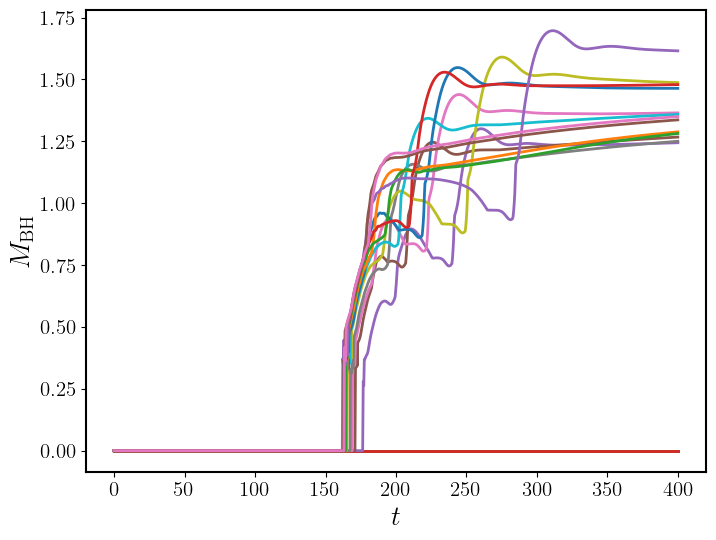

In [89]:
# Plot Mbh vs t
for run_name, run in data.items():    
    plt.plot(run["t"], run["bh_mass"], label=r"$A =$"+" "+str(run["ampl"]))

plt.ylabel(r"$M_\mathrm{BH}$")
plt.xlabel(r"$t$")

# plt.legend(loc="best")
plt.show()